# 04 Driving Postprocess From Lane Candidates - finetune_v1

이 노트북의 목적은 **lane detector 출력 좌표를 실제 주행 판단값으로 바꾸는 것**임.

이전 노트북까지 정리된 흐름:

```text
00 Colab fine-tuning
01 학습 결과 확인
02 holdout에서 pretrained vs fine-tuned 시각 비교
03 공식 repo 방식 lane detector 후처리 설정 확인
```

03에서 일단 lane candidate를 뽑는 detector 설정은 아래를 primary로 정했음.

```text
conf_threshold = 0.20
nms_thres = 50
max_lanes = 2
```

하지만 이 값은 아직 조향값이 아님.  
모델은 매 프레임마다 아래처럼 lane 후보 좌표들을 반환할 뿐임.

```text
lane candidate 1: [(x1, y1), (x2, y2), ...]
lane candidate 2: [(x1, y1), (x2, y2), ...]
```

이번 노트북에서 해야 할 일:

```text
lane candidates
-> left/right lane 후보 선택
-> 도로 중앙 center_x 추정
-> 차량 중심과의 error 계산
-> confidence/mode/reason 부여
-> 짧은 시계열 smoothing 적용
```

즉 이번 노트북은 **모델 후처리와 제어 사이의 연결부**를 만드는 작업임.

## 1. 경로와 주요 파라미터

이번 노트북은 03에서 저장한 `finetuned_forward_cache_full_holdout.pkl`을 재사용함.  
따라서 모델 forward를 다시 수행하지 않고, 저장된 raw output에 대해 후보 디코딩과 주행 후처리만 반복함.

주행 후처리에서 중요한 설정은 detector 설정과 별개임.

- `LOOKAHEAD_Y_RATIO`: 이미지 아래쪽 어느 높이에서 조향 기준 x를 읽을지.
- `EXPECTED_LANE_WIDTH_PX`: 한쪽 lane만 보일 때 도로 중앙을 추정하기 위한 차로 폭.
- `CENTER_SMOOTH_ALPHA`: 현재 center와 이전 center를 얼마나 섞을지.
- `MAX_LOST_HOLD_FRAMES`: lane이 잠깐 사라졌을 때 이전 center를 몇 프레임 유지할지.

이번 노트북에서는 이 값들을 바로 최종 확정하지 않고, holdout/overlay를 보며 “1차 주행 스크립트로 옮길 수 있는 기본값”을 정리하는 것이 목표임.

In [1]:
from pathlib import Path
import sys
import os
import json
import pickle
from dataclasses import dataclass

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r'~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization')
EXP_ROOT = PROJECT_ROOT / '10_experiments' / '06_lane_model_finetuning'
OUTPUT_ROOT = EXP_ROOT / 'colab_outputs' / 'finetune_v1'
FULL_ROOT = OUTPUT_ROOT / 'MapLane_Field1Field2_full'
HOLDOUT_ROOT = PROJECT_ROOT / '30_pipelines' / 'culane_pseudo_dataset_builder' / 'datasets' / 'map_culane_holdout_eval_component_poly'

PREV_REVIEW_ROOT = EXP_ROOT / 'review_outputs' / '03_official_lane_detector_postprocess_review_finetune_v1'
FORWARD_CACHE_PATH = PREV_REVIEW_ROOT / 'finetuned_forward_cache_full_holdout.pkl'

REVIEW_ROOT = EXP_ROOT / 'review_outputs' / '04_driving_postprocess_from_lane_candidates'
OVERLAY_DIR = REVIEW_ROOT / 'overlays'
CSV_DIR = REVIEW_ROOT / 'tables'
REVIEW_ROOT.mkdir(parents=True, exist_ok=True)
OVERLAY_DIR.mkdir(parents=True, exist_ok=True)
CSV_DIR.mkdir(parents=True, exist_ok=True)

# 03에서 정한 primary detector 설정.
PRIMARY_DETECTOR = {'conf_threshold': 0.20, 'nms_thres': 50, 'max_lanes': 2}

# 후보가 너무 적을 때 비교용으로 볼 recall-biased detector 설정.
RECALL_DETECTOR = {'conf_threshold': 0.20, 'nms_thres': 50, 'max_lanes': 4}

# 카메라/모델 좌표계. pseudo CULane dataset builder와 동일해야 함.
RAW_W = 1296
RAW_H = 972
CUT_HEIGHT = 445
VISIBLE_H = RAW_H - CUT_HEIGHT
IMAGE_CENTER_X = RAW_W / 2

# 주행 판단 기준 y. visible 영역 아래쪽 78% 지점에서 x를 읽음.
LOOKAHEAD_Y_RATIO = 0.78
LOOKAHEAD_Y = CUT_HEIGHT + VISIBLE_H * LOOKAHEAD_Y_RATIO

# single-frame lane filtering.
MIN_LANE_POINTS = 6
MIN_Y_SPAN = 70
MIN_VALID_Y_NEAR_LOOKAHEAD = 90

# temporal smoothing.
CENTER_SMOOTH_ALPHA = 0.35
MAX_LOST_HOLD_FRAMES = 4

SUMMARY_CSV = CSV_DIR / 'driving_postprocess_summary.csv'
FRAME_CSV = CSV_DIR / 'driving_postprocess_frame_results.csv'

print('FORWARD_CACHE_PATH:', FORWARD_CACHE_PATH, 'exists=', FORWARD_CACHE_PATH.exists())
print('LOOKAHEAD_Y:', round(LOOKAHEAD_Y, 1), 'IMAGE_CENTER_X:', IMAGE_CENTER_X)
assert FORWARD_CACHE_PATH.exists(), '먼저 03 노트북을 실행해 full holdout forward cache를 만들어야 함.'

FORWARD_CACHE_PATH: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\03_official_lane_detector_postprocess_review_finetune_v1\finetuned_forward_cache_full_holdout.pkl exists= True
LOOKAHEAD_Y: 856.1 IMAGE_CENTER_X: 648.0


## 2. fine-tuned 모델 code snapshot 로딩

03 노트북과 동일하게 Colab full fine-tuning 결과 안의 `code/` snapshot을 사용함.

이유:

- `raw_output`은 이미 cache에 있지만, 공식 `get_lanes()` 디코딩은 `model.heads` 구현을 사용함.
- 학습 당시 코드와 다른 코드로 디코딩하면 결과가 달라질 수 있음.
- 따라서 `colab_outputs/finetune_v1/.../code`를 그대로 import함.

In [2]:
def win_long_path(path):
    p = Path(path)
    s = str(p if p.is_absolute() else p.resolve())
    if os.name == 'nt' and not s.startswith('\\\\?\\'):
        return '\\\\?\\' + s
    return s


def read_text_any(path):
    path = Path(path)
    for enc in ['utf-8', 'utf-8-sig', 'cp949']:
        try:
            return path.read_text(encoding=enc)
        except UnicodeDecodeError:
            continue
    return path.read_text(encoding='utf-8', errors='replace')


def cv2_imread_color(path):
    # Windows 긴 경로/한글 경로 대응.
    data = np.fromfile(win_long_path(path), dtype=np.uint8)
    if data.size == 0:
        return None
    return cv2.imdecode(data, cv2.IMREAD_COLOR)


def cv2_imwrite(path, image):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    ext = path.suffix or '.png'
    ok, buf = cv2.imencode(ext, image)
    if not ok:
        raise RuntimeError(f'failed to encode image: {path}')
    buf.tofile(win_long_path(path))


def find_single_run_dir(root: Path) -> Path:
    runs = sorted([p for p in root.iterdir() if p.is_dir()])
    if len(runs) != 1:
        print('run dirs:')
        for p in runs:
            print(' -', p)
        raise RuntimeError(f'expected exactly one run dir under {root}, got {len(runs)}')
    return runs[0]


FULL_RUN = find_single_run_dir(FULL_ROOT)
CODE_DIR = FULL_RUN / 'code'
CONFIG_PATH = FULL_RUN / 'config.py'
FINETUNED_PTH = FULL_RUN / 'ckpt' / 'best.pth'

print('FULL_RUN:', FULL_RUN)
print('CODE_DIR:', CODE_DIR, CODE_DIR.exists())
print('CONFIG_PATH:', CONFIG_PATH, CONFIG_PATH.exists())
print('FINETUNED_PTH:', FINETUNED_PTH, FINETUNED_PTH.exists())

assert CODE_DIR.exists()
assert CONFIG_PATH.exists()
assert FINETUNED_PTH.exists()

FULL_RUN: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1\MapLane_Field1Field2_full\20260505_201647_lr_1e-04_b_8
CODE_DIR: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1\MapLane_Field1Field2_full\20260505_201647_lr_1e-04_b_8\code True
CONFIG_PATH: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1\MapLane_Field1Field2_full\20260505_201647_lr_1e-04_b_8\config.py True
FINETUNED_PTH: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1\MapLane_Field1Field2_full\20260505_201647_lr_1e-04_b_8\ckpt\best.pth True


In [3]:
import torch

# 이전 import 잔여물이 있으면 학습 당시 code snapshot이 아니라 다른 CLRKDNet 코드가 잡힐 수 있음.
for module_name in list(sys.modules):
    if module_name == 'clrkd' or module_name.startswith('clrkd.') or module_name == 'mmcv' or module_name.startswith('mmcv.'):
        del sys.modules[module_name]

if str(CODE_DIR) in sys.path:
    sys.path.remove(str(CODE_DIR))
sys.path.insert(0, str(CODE_DIR))

from clrkd.utils.config import Config
import clrkd.models
from clrkd.models.registry import build_net


def load_config_windows_safe(config_path: Path):
    text = read_text_any(config_path)
    namespace = {}
    exec(compile(text, str(config_path), 'exec'), namespace)
    cfg_dict = {k: v for k, v in namespace.items() if not k.startswith('__')}
    return Config(cfg_dict, cfg_text=text, filename=str(config_path))


def torch_load(path: Path):
    try:
        return torch.load(win_long_path(path), map_location=DEVICE, weights_only=False)
    except TypeError:
        return torch.load(win_long_path(path), map_location=DEVICE)


def clean_state_dict(raw_state):
    cleaned = {}
    for k, v in raw_state.items():
        if k.startswith('module.'):
            k = k[len('module.'):]
        cleaned[k] = v
    return cleaned


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('torch:', torch.__version__)
print('DEVICE:', DEVICE)

cfg = load_config_windows_safe(CONFIG_PATH)
model = build_net(cfg)

ckpt = torch_load(FINETUNED_PTH)
raw_state = ckpt['net'] if isinstance(ckpt, dict) and 'net' in ckpt else ckpt
state = clean_state_dict(raw_state)

missing, unexpected = model.load_state_dict(state, strict=False)
model = model.to(DEVICE).eval()

print('missing keys:', len(missing))
print('unexpected keys:', len(unexpected))

torch: 2.11.0+cpu
DEVICE: cpu
missing keys: 0
unexpected keys: 0


## 3. 03 forward cache 읽기

cache에는 holdout usable 722장에 대해 아래 정보가 저장되어 있음.

- 원본 이미지 경로
- pseudo GT `.lines.txt`
- fine-tuned 모델의 raw output tensor

이번 노트북은 이 raw output을 detector 설정별로 다시 디코딩하고, 그 뒤 주행용 center를 계산함.

In [4]:
with open(win_long_path(FORWARD_CACHE_PATH), 'rb') as f:
    forward_cache = pickle.load(f)

samples = forward_cache['samples']
print('cache keys:', forward_cache.keys())
print('samples:', len(samples))
print('first sample keys:', samples[0].keys())
print('scene counts:')
print(pd.Series([s['scene'] for s in samples]).value_counts())

assert len(samples) > 0
assert 'raw_output' in samples[0]

cache keys: dict_keys(['settings', 'samples'])
samples: 722
first sample keys: dict_keys(['index', 'scene', 'rel', 'img_path', 'lines_path', 'gt', 'raw_output'])
scene counts:
field1_sign_background       413
field2_traffic_background    309
Name: count, dtype: int64


## 4. 공식 lane 후보 디코딩 함수

여기까지는 여전히 공식 detector 후처리 영역임.

```text
raw_output
-> confidence threshold
-> NMS
-> top-k(max_lanes)
-> lane coordinate list
```

이 함수가 반환하는 `pred_lanes`는 아직 left/right가 아님.  
그냥 모델이 뽑은 lane 후보 목록임.

In [5]:
@dataclass(frozen=True)
class DetectorSetting:
    conf_threshold: float
    nms_thres: int
    max_lanes: int

    @property
    def name(self):
        return f'conf{self.conf_threshold:.2f}_nms{self.nms_thres}_max{self.max_lanes}'


PRIMARY_SETTING = DetectorSetting(**PRIMARY_DETECTOR)
RECALL_SETTING = DetectorSetting(**RECALL_DETECTOR)


def apply_detector_setting(setting: DetectorSetting):
    model.heads.cfg.test_parameters.conf_threshold = float(setting.conf_threshold)
    model.heads.cfg.test_parameters.nms_thres = int(setting.nms_thres)
    model.heads.cfg.max_lanes = int(setting.max_lanes)


def lane_to_serial(lane):
    pts = lane.to_array(cfg)
    if pts is None or len(pts) < 2:
        return None
    score = lane.metadata.get('conf', None)
    try:
        score = float(score.detach().cpu()) if hasattr(score, 'detach') else float(score)
    except Exception:
        score = None
    return {'points': pts.tolist(), 'score': score}


def decode_raw_output(raw_output_cpu, setting: DetectorSetting):
    apply_detector_setting(setting)
    output = raw_output_cpu.clone().to(DEVICE)
    with torch.no_grad():
        lanes = model.heads.get_lanes(output, as_lanes=True)[0]
    serial = []
    for lane in lanes:
        item = lane_to_serial(lane)
        if item is not None:
            serial.append(item)
    return serial


for setting in [PRIMARY_SETTING, RECALL_SETTING]:
    pred = decode_raw_output(samples[0]['raw_output'], setting)
    print(setting.name, 'pred_lanes=', len(pred), 'scores=', [round(p['score'], 3) if p['score'] is not None else None for p in pred])

conf0.20_nms50_max2 pred_lanes= 2 scores= [0.095, -0.007]
conf0.20_nms50_max4 pred_lanes= 4 scores= [0.095, -0.007, -0.073, -0.144]


## 5. 좌표 보간과 lane feature 계산

모델 출력 lane은 여러 `(x, y)` 점의 모음임.  
주행에는 모든 점이 필요한 것이 아니라, 우선 특정 높이에서의 x좌표가 중요함.

예를 들어 `LOOKAHEAD_Y`에서:

```text
left_lane_x  = 왼쪽 차선이 그 y에서 갖는 x
right_lane_x = 오른쪽 차선이 그 y에서 갖는 x
center_x     = (left_lane_x + right_lane_x) / 2
```

이 작업을 하려면 lane 곡선을 따라 `y = LOOKAHEAD_Y`에서 x를 보간해야 함.

In [6]:
def lane_points(lane_item):
    pts = np.array(lane_item['points'], dtype=np.float32)
    pts = pts[np.isfinite(pts).all(axis=1)]
    if len(pts) < 2:
        return np.empty((0, 2), dtype=np.float32)
    df = (
        pd.DataFrame(pts, columns=['x', 'y'])
        .groupby('y', as_index=False)['x']
        .mean()
        .sort_values('y')
    )
    return df[['x', 'y']].to_numpy(dtype=np.float32)


def interp_x_at_y(pts, y):
    if len(pts) < 2:
        return np.nan
    xs = pts[:, 0]
    ys = pts[:, 1]
    order = np.argsort(ys)
    ys = ys[order]
    xs = xs[order]
    if y < ys.min() or y > ys.max():
        return np.nan
    return float(np.interp(y, ys, xs))


def nearest_x_to_y(pts, y):
    if len(pts) == 0:
        return np.nan, np.inf
    idx = int(np.argmin(np.abs(pts[:, 1] - y)))
    return float(pts[idx, 0]), float(abs(pts[idx, 1] - y))


def lane_feature(lane_item, lookahead_y=LOOKAHEAD_Y):
    pts = lane_points(lane_item)
    if len(pts) < 2:
        return None
    y_min, y_max = float(pts[:, 1].min()), float(pts[:, 1].max())
    y_span = y_max - y_min

    x_lookahead = interp_x_at_y(pts, lookahead_y)
    used_interpolation = True
    y_distance = 0.0
    if not np.isfinite(x_lookahead):
        x_lookahead, y_distance = nearest_x_to_y(pts, lookahead_y)
        used_interpolation = False

    if not np.isfinite(x_lookahead):
        return None

    side = 'left' if x_lookahead < IMAGE_CENTER_X else 'right'
    score = lane_item.get('score', None)
    quality = y_span + len(pts) * 2 - y_distance * 0.5

    return {
        'points': pts,
        'score': score,
        'x': float(x_lookahead),
        'side': side,
        'y_min': y_min,
        'y_max': y_max,
        'y_span': float(y_span),
        'num_points': int(len(pts)),
        'y_distance': float(y_distance),
        'used_interpolation': bool(used_interpolation),
        'quality': float(quality),
    }


def filter_lane_features(lanes):
    feats = []
    for lane in lanes:
        feat = lane_feature(lane)
        if feat is None:
            continue
        if feat['num_points'] < MIN_LANE_POINTS:
            continue
        if feat['y_span'] < MIN_Y_SPAN:
            continue
        if feat['y_distance'] > MIN_VALID_Y_NEAR_LOOKAHEAD:
            continue
        feats.append(feat)
    return feats


test_preds = decode_raw_output(samples[0]['raw_output'], PRIMARY_SETTING)
test_feats = filter_lane_features(test_preds)
pd.DataFrame([{k: v for k, v in f.items() if k != 'points'} for f in test_feats])

,score,x,side,y_min,y_max,y_span,num_points,y_distance,used_interpolation,quality
0,0.094568,330.93818,left,591.0,971.0,380.0,20,0.0,True,420.0
1,-0.006909,329.37393,left,591.0,971.0,380.0,20,0.0,True,420.0


## 6. 한쪽 lane만 보일 때 사용할 lane width 추정

양쪽 lane이 모두 보이면 center는 간단함.

```text
center_x = (left_x + right_x) / 2
```

하지만 곡선/교차로/카메라 각도 때문에 한쪽 lane만 보이는 경우가 많음.  
이때는 `EXPECTED_LANE_WIDTH_PX`를 이용해서 center를 추정함.

```text
left only  -> center_x = left_x  + lane_width / 2
right only -> center_x = right_x - lane_width / 2
```

아래 셀에서는 pseudo GT 기준으로 lookahead 위치의 좌우 lane 간격 median을 계산함.

width samples: 434
EXPECTED_LANE_WIDTH_PX: 889.7
LANE_WIDTH_MIN/MAX: 400.4 1690.4


,scene,count,mean,median,std
0,field1_sign_background,253,886.969680,890.450368,87.717682
1,field2_traffic_background,181,892.050089,887.990259,91.349528


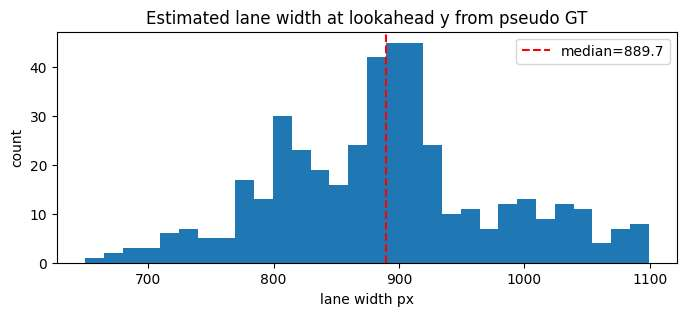

In [7]:
def read_lines_txt(lines_path: Path):
    lanes = []
    text = read_text_any(lines_path)
    for line in text.splitlines():
        vals = [float(x) for x in line.strip().split()]
        if len(vals) < 4:
            continue
        pts = np.array(vals, dtype=np.float32).reshape(-1, 2)
        lanes.append({'points': pts.tolist(), 'score': None})
    return lanes


def estimate_lane_width_from_gt(samples, lookahead_y=LOOKAHEAD_Y):
    widths = []
    rows = []
    for sample in samples:
        gts = sample['gt']
        feats = filter_lane_features(gts)
        lefts = [f for f in feats if f['side'] == 'left']
        rights = [f for f in feats if f['side'] == 'right']
        if not lefts or not rights:
            continue
        left = sorted(lefts, key=lambda f: f['x'], reverse=True)[0]
        right = sorted(rights, key=lambda f: f['x'])[0]
        gap = right['x'] - left['x']
        if 80 <= gap <= 1100:
            widths.append(gap)
            rows.append({'scene': sample['scene'], 'gap': gap})
    return np.array(widths, dtype=np.float32), pd.DataFrame(rows)


widths, width_df = estimate_lane_width_from_gt(samples)
EXPECTED_LANE_WIDTH_PX = float(np.nanmedian(widths)) if len(widths) else 520.0
LANE_WIDTH_MIN = EXPECTED_LANE_WIDTH_PX * 0.45
LANE_WIDTH_MAX = EXPECTED_LANE_WIDTH_PX * 1.90

print('width samples:', len(widths))
print('EXPECTED_LANE_WIDTH_PX:', round(EXPECTED_LANE_WIDTH_PX, 1))
print('LANE_WIDTH_MIN/MAX:', round(LANE_WIDTH_MIN, 1), round(LANE_WIDTH_MAX, 1))

display(width_df.groupby('scene')['gap'].agg(['count', 'mean', 'median', 'std']).reset_index())

plt.figure(figsize=(8, 3))
plt.hist(widths, bins=30)
plt.axvline(EXPECTED_LANE_WIDTH_PX, color='red', linestyle='--', label=f'median={EXPECTED_LANE_WIDTH_PX:.1f}')
plt.title('Estimated lane width at lookahead y from pseudo GT')
plt.xlabel('lane width px')
plt.ylabel('count')
plt.legend()
plt.show()

## 7. Single-frame driving postprocess

이제 한 프레임의 lane candidates에서 주행 판단값을 만듦.

반환값:

- `mode`: `both`, `left_only`, `right_only`, `lost`, `bad_pair`
- `center_x`: 주행 기준 중앙선 x
- `error_px`: `center_x - image_center_x`
- `error_norm`: 이미지 반폭으로 정규화한 error
- `confidence`: 후속 제어에서 속도를 조절할 때 사용할 신뢰도
- `reason`: 왜 그렇게 판단했는지

여기서 중요한 점:

> lane detector는 좌표 후보를 만들고, driving postprocess가 주행 의미를 부여함.

In [8]:
def select_lane_pair(features):
    if not features:
        return None, None

    lefts = [f for f in features if f['side'] == 'left']
    rights = [f for f in features if f['side'] == 'right']

    # 왼쪽 차선은 화면 중앙에 가장 가까운 왼쪽 후보, 오른쪽 차선은 화면 중앙에 가장 가까운 오른쪽 후보를 우선함.
    # quality는 y-span이 긴 후보를 약하게 보정하기 위해 함께 사용함.
    left = None
    right = None
    if lefts:
        left = sorted(lefts, key=lambda f: (f['x'], f['quality']), reverse=True)[0]
    if rights:
        right = sorted(rights, key=lambda f: (f['x'], -f['quality']))[0]
    return left, right


def compute_single_frame_drive(lanes, detector_name='unknown'):
    feats = filter_lane_features(lanes)
    left, right = select_lane_pair(feats)

    result = {
        'detector': detector_name,
        'num_lanes_raw': len(lanes),
        'num_lanes_filtered': len(feats),
        'mode': 'lost',
        'center_x': np.nan,
        'error_px': np.nan,
        'error_norm': np.nan,
        'confidence': 0.0,
        'left_x': np.nan,
        'right_x': np.nan,
        'lane_gap': np.nan,
        'reason': 'no_valid_lane',
        'left': left,
        'right': right,
        'features': feats,
    }

    if left is not None:
        result['left_x'] = left['x']
    if right is not None:
        result['right_x'] = right['x']

    if left is not None and right is not None:
        gap = right['x'] - left['x']
        result['lane_gap'] = gap
        if LANE_WIDTH_MIN <= gap <= LANE_WIDTH_MAX:
            center_x = (left['x'] + right['x']) / 2
            mode = 'both'
            confidence = 1.0
            reason = 'valid_pair'
        else:
            # 양쪽이 있다고 해도 gap이 말이 안 되면 더 좋은 한쪽 후보만으로 fallback.
            if abs(left['x'] - IMAGE_CENTER_X) < abs(right['x'] - IMAGE_CENTER_X):
                center_x = left['x'] + EXPECTED_LANE_WIDTH_PX / 2
                mode = 'left_only'
                confidence = 0.45
                reason = 'bad_pair_fallback_left'
            else:
                center_x = right['x'] - EXPECTED_LANE_WIDTH_PX / 2
                mode = 'right_only'
                confidence = 0.45
                reason = 'bad_pair_fallback_right'
    elif left is not None:
        center_x = left['x'] + EXPECTED_LANE_WIDTH_PX / 2
        mode = 'left_only'
        confidence = 0.55
        reason = 'left_only_width_prior'
    elif right is not None:
        center_x = right['x'] - EXPECTED_LANE_WIDTH_PX / 2
        mode = 'right_only'
        confidence = 0.55
        reason = 'right_only_width_prior'
    else:
        return result

    # 중심 추정이 화면 밖으로 너무 많이 나가면 신뢰도를 낮춤.
    if center_x < -RAW_W * 0.25 or center_x > RAW_W * 1.25:
        confidence *= 0.35
        reason += '_center_outside'

    error_px = center_x - IMAGE_CENTER_X
    result.update({
        'mode': mode,
        'center_x': float(center_x),
        'error_px': float(error_px),
        'error_norm': float(error_px / (RAW_W / 2)),
        'confidence': float(confidence),
        'reason': reason,
    })
    return result


sample = samples[0]
preds = decode_raw_output(sample['raw_output'], PRIMARY_SETTING)
drive = compute_single_frame_drive(preds, PRIMARY_SETTING.name)
{k: v for k, v in drive.items() if k not in ['left', 'right', 'features']}

{'detector': 'conf0.20_nms50_max2',
 'num_lanes_raw': 2,
 'num_lanes_filtered': 2,
 'mode': 'left_only',
 'center_x': 775.7887044677734,
 'error_px': 127.78870446777341,
 'error_norm': 0.19720479084532935,
 'confidence': 0.55,
 'left_x': 330.9381795654297,
 'right_x': nan,
 'lane_gap': nan,
 'reason': 'left_only_width_prior'}

## 8. pseudo GT center와 비교하는 local 지표

이번 노트북의 평가는 완전한 주행 성능 평가가 아님.  
맵 위에서 실제로 차를 굴려야 최종 판단이 가능함.

그래도 holdout의 pseudo GT `.lines.txt`를 이용하면 다음 정도는 볼 수 있음.

```text
prediction lanes -> predicted center_x
pseudo GT lanes   -> target center_x
abs_center_error = |predicted center_x - target center_x|
```

이 값이 낮을수록 detector 후보를 주행 중심선으로 잘 바꾸고 있다는 뜻임.  
단, pseudo GT 자체가 HSV 기반 자동 라벨이므로 절대 정답은 아님.

In [9]:
def target_center_from_gt(gt_lanes):
    # GT도 같은 postprocess를 통과시켜 center를 구함.
    return compute_single_frame_drive(gt_lanes, detector_name='pseudo_gt')


def compact_drive_result(result):
    keep = [
        'detector', 'num_lanes_raw', 'num_lanes_filtered', 'mode',
        'center_x', 'error_px', 'error_norm', 'confidence',
        'left_x', 'right_x', 'lane_gap', 'reason'
    ]
    return {k: result.get(k) for k in keep}


def run_single_frame_eval(setting: DetectorSetting):
    rows = []
    for sample in samples:
        pred_lanes = decode_raw_output(sample['raw_output'], setting)
        pred_drive = compute_single_frame_drive(pred_lanes, setting.name)
        gt_drive = target_center_from_gt(sample['gt'])

        pred_center = pred_drive['center_x']
        gt_center = gt_drive['center_x']
        abs_center_error = np.nan
        if np.isfinite(pred_center) and np.isfinite(gt_center):
            abs_center_error = abs(pred_center - gt_center)

        row = {
            'sample_index': sample['index'],
            'scene': sample['scene'],
            'file': Path(sample['rel']).name,
            'setting': setting.name,
            'gt_mode': gt_drive['mode'],
            'gt_center_x': gt_center,
            'pred_mode': pred_drive['mode'],
            'pred_center_x': pred_center,
            'abs_center_error_px': abs_center_error,
            'pred_error_norm': pred_drive['error_norm'],
            'pred_confidence': pred_drive['confidence'],
            'pred_reason': pred_drive['reason'],
            'pred_num_lanes': pred_drive['num_lanes_raw'],
            'pred_num_lanes_filtered': pred_drive['num_lanes_filtered'],
            'gt_num_lanes': gt_drive['num_lanes_raw'],
        }
        rows.append(row)
    return pd.DataFrame(rows)


primary_df = run_single_frame_eval(PRIMARY_SETTING)
recall_df = run_single_frame_eval(RECALL_SETTING)

frame_df = pd.concat([primary_df, recall_df], ignore_index=True)
frame_df.to_csv(win_long_path(FRAME_CSV), index=False, encoding='utf-8-sig')

def summarize_frame_eval(df):
    valid = df[np.isfinite(df['abs_center_error_px'])].copy()
    return {
        'frames': len(df),
        'valid_center_frames': len(valid),
        'lost_frames': int((df['pred_mode'] == 'lost').sum()),
        'mean_abs_center_error_px': float(valid['abs_center_error_px'].mean()) if len(valid) else np.nan,
        'median_abs_center_error_px': float(valid['abs_center_error_px'].median()) if len(valid) else np.nan,
        'p90_abs_center_error_px': float(valid['abs_center_error_px'].quantile(0.90)) if len(valid) else np.nan,
        'mean_confidence': float(df['pred_confidence'].mean()),
    }


summary = pd.DataFrame([
    {'setting': PRIMARY_SETTING.name, **summarize_frame_eval(primary_df)},
    {'setting': RECALL_SETTING.name, **summarize_frame_eval(recall_df)},
])
summary.to_csv(win_long_path(SUMMARY_CSV), index=False, encoding='utf-8-sig')
display(summary)

print('mode distribution: primary')
display(primary_df['pred_mode'].value_counts())
print('mode distribution: recall')
display(recall_df['pred_mode'].value_counts())

,setting,frames,valid_center_frames,lost_frames,mean_abs_center_error_px,median_abs_center_error_px,p90_abs_center_error_px,mean_confidence
0,conf0.20_nms50_max2,722,676,36,45.064849,18.110028,91.419460,0.571884
1,conf0.20_nms50_max4,722,687,24,35.849875,9.288468,70.769376,0.726039


mode distribution: primary


pred_mode
left_only     327
right_only    279
both           80
lost           36
Name: count, dtype: int64

mode distribution: recall


pred_mode
both          314
left_only     238
right_only    146
lost           24
Name: count, dtype: int64

## 9. 대표 overlay 확인

아래 이미지는 한 프레임에서 후처리가 어떤 판단을 내렸는지 보여줌.

표시 규칙:

- 회색 얇은 선: detector가 반환한 전체 lane 후보
- 파란 선: 선택된 left lane
- 빨간 선: 선택된 right lane
- 초록 세로선/점: 추정한 주행 center
- 흰 세로선: 카메라 이미지 중심

여기서 봐야 하는 것은 “lane 선이 예쁜가”보다, **초록 center가 실제로 차가 따라갈 만한 위치에 있는가**임.

,sample_index,scene,file,mode,center_x,error_px,confidence,reason,overlay
0,0,field1_sign_background,20260430_175024_signs_background_moving_mixed_...,left_only,775.788704,127.788704,0.55,left_only_width_prior,~\02_Projects\University\26-1_Em...
1,82,field1_sign_background,20260430_175043_signs_background_moving_mixed_...,right_only,486.058744,-161.941256,0.55,right_only_width_prior,~\02_Projects\University\26-1_Em...
2,165,field1_sign_background,20260430_175101_signs_background_moving_mixed_...,right_only,216.801787,-431.198213,0.55,right_only_width_prior,~\02_Projects\University\26-1_Em...
3,247,field1_sign_background,20260430_175119_signs_background_moving_mixed_...,left_only,581.339176,-66.660824,0.55,left_only_width_prior,~\02_Projects\University\26-1_Em...
4,330,field1_sign_background,20260430_175138_signs_background_moving_mixed_...,left_only,1084.896758,436.896758,0.55,left_only_width_prior,~\02_Projects\University\26-1_Em...
5,412,field1_sign_background,20260430_175156_signs_background_moving_mixed_...,both,711.240540,63.240540,1.00,valid_pair,~\02_Projects\University\26-1_Em...
6,413,field2_traffic_background,20260501_123424_07_traffic_capture_background_...,right_only,724.744849,76.744849,0.55,right_only_width_prior,~\02_Projects\University\26-1_Em...
7,475,field2_traffic_background,20260501_123441_07_traffic_capture_background_...,right_only,705.867703,57.867703,0.55,right_only_width_prior,~\02_Projects\University\26-1_Em...
8,536,field2_traffic_background,20260501_123500_07_traffic_capture_background_...,right_only,584.541188,-63.458812,0.55,right_only_width_prior,~\02_Projects\University\26-1_Em...
9,598,field2_traffic_background,20260501_123518_07_traffic_capture_background_...,right_only,377.941452,-270.058548,0.55,right_only_width_prior,~\02_Projects\University\26-1_Em...


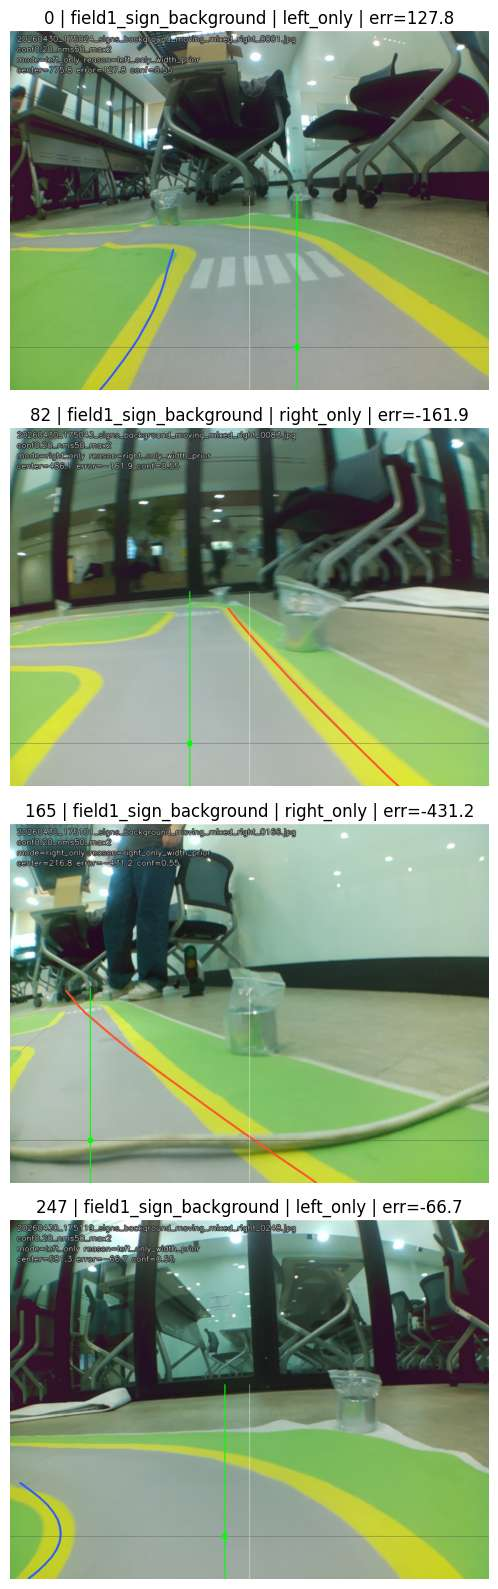

In [10]:
def draw_points_line(img, pts, color, thickness=2):
    if pts is None or len(pts) < 2:
        return
    arr = np.array(pts, dtype=np.float32)
    arr = arr[np.isfinite(arr).all(axis=1)]
    if len(arr) < 2:
        return
    arr = arr[np.argsort(arr[:, 1])]
    cv2.polylines(img, [arr.astype(np.int32)], False, color, thickness, lineType=cv2.LINE_AA)


def draw_drive_overlay(sample, setting: DetectorSetting, out_path=None):
    img_bgr = cv2_imread_color(sample['img_path'])
    if img_bgr is None:
        raise RuntimeError(f'failed to read image: {sample["img_path"]}')
    pred_lanes = decode_raw_output(sample['raw_output'], setting)
    result = compute_single_frame_drive(pred_lanes, setting.name)

    vis = img_bgr.copy()
    # 전체 후보
    for lane in pred_lanes:
        draw_points_line(vis, lane_points(lane), (160, 160, 160), 1)

    # 선택된 좌/우
    if result['left'] is not None:
        draw_points_line(vis, result['left']['points'], (255, 90, 40), 3)
    if result['right'] is not None:
        draw_points_line(vis, result['right']['points'], (40, 80, 255), 3)

    # 기준 y와 center
    y = int(round(LOOKAHEAD_Y))
    cv2.line(vis, (0, y), (RAW_W - 1, y), (80, 80, 80), 1)
    cv2.line(vis, (int(IMAGE_CENTER_X), CUT_HEIGHT), (int(IMAGE_CENTER_X), RAW_H - 1), (255, 255, 255), 1)
    if np.isfinite(result['center_x']):
        cx = int(round(result['center_x']))
        cv2.line(vis, (cx, CUT_HEIGHT), (cx, RAW_H - 1), (0, 255, 0), 2)
        cv2.circle(vis, (cx, y), 8, (0, 255, 0), -1)

    text_lines = [
        f'{Path(sample["rel"]).name}',
        f'{setting.name}',
        f'mode={result["mode"]} reason={result["reason"]}',
        f'center={result["center_x"]:.1f} error={result["error_px"]:.1f} conf={result["confidence"]:.2f}',
    ]
    yy = 28
    for text in text_lines:
        cv2.putText(vis, text, (18, yy), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (20, 20, 20), 3, cv2.LINE_AA)
        cv2.putText(vis, text, (18, yy), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 1, cv2.LINE_AA)
        yy += 28

    if out_path is not None:
        cv2_imwrite(out_path, vis)
    return vis, result


# scene별 대표 샘플 몇 장 저장.
sample_indices = []
sample_df = pd.DataFrame([{'index': s['index'], 'scene': s['scene'], 'rel': s['rel']} for s in samples])
for scene, group in sample_df.groupby('scene'):
    group = group.sort_values('rel').reset_index(drop=True)
    idx = np.linspace(0, len(group) - 1, min(6, len(group))).round().astype(int)
    sample_indices.extend(group.iloc[idx]['index'].astype(int).tolist())

saved = []
for idx in sample_indices:
    sample = samples[idx]
    out_path = OVERLAY_DIR / f'{idx:04d}_{sample["scene"]}_{PRIMARY_SETTING.name}.png'
    vis, result = draw_drive_overlay(sample, PRIMARY_SETTING, out_path)
    saved.append({'sample_index': idx, 'scene': sample['scene'], 'file': Path(sample['rel']).name, **compact_drive_result(result), 'overlay': str(out_path)})

saved_df = pd.DataFrame(saved)
display(saved_df[['sample_index', 'scene', 'file', 'mode', 'center_x', 'error_px', 'confidence', 'reason', 'overlay']])

# 첫 몇 장은 노트북에 직접 표시.
show_n = min(4, len(saved))
fig, axes = plt.subplots(show_n, 1, figsize=(12, 4 * show_n))
if show_n == 1:
    axes = [axes]
for ax, row in zip(axes, saved[:show_n]):
    img = cv2.cvtColor(cv2_imread_color(row['overlay']), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'{row["sample_index"]} | {row["scene"]} | {row["mode"]} | err={row["error_px"]:.1f}')
plt.tight_layout()
plt.show()

## 10. 어려운 케이스 확인

다음 셀은 primary setting에서 center error가 크거나 lane을 잃은 케이스를 골라 overlay를 저장함.

이 케이스들을 보는 이유:

- 주행 중 이탈할 가능성이 높은 상황을 찾기 위함.
- detector 설정 문제가 아니라 postprocess 정책 문제인지 구분하기 위함.
- one-lane fallback, smoothing, 감속 조건을 어디에 넣어야 하는지 판단하기 위함.

,sample_index,scene,file,gt_mode,pred_mode,abs_center_error_px,pred_confidence,pred_reason
0,32,field1_sign_background,20260430_175032_signs_background_moving_mixed_...,both,lost,NaN,0.0,no_valid_lane
1,75,field1_sign_background,20260430_175041_signs_background_moving_mixed_...,both,lost,NaN,0.0,no_valid_lane
2,135,field1_sign_background,20260430_175054_signs_background_moving_mixed_...,both,lost,NaN,0.0,no_valid_lane
3,136,field1_sign_background,20260430_175055_signs_background_moving_mixed_...,right_only,lost,NaN,0.0,no_valid_lane
4,137,field1_sign_background,20260430_175055_signs_background_moving_mixed_...,lost,lost,NaN,0.0,no_valid_lane
5,185,field1_sign_background,20260430_175105_signs_background_moving_mixed_...,left_only,lost,NaN,0.0,no_valid_lane
6,186,field1_sign_background,20260430_175106_signs_background_moving_mixed_...,left_only,lost,NaN,0.0,no_valid_lane
7,187,field1_sign_background,20260430_175106_signs_background_moving_mixed_...,lost,lost,NaN,0.0,no_valid_lane
8,188,field1_sign_background,20260430_175106_signs_background_moving_mixed_...,left_only,lost,NaN,0.0,no_valid_lane
9,189,field1_sign_background,20260430_175106_signs_background_moving_mixed_...,left_only,lost,NaN,0.0,no_valid_lane


saved hard overlays: 16
~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\04_driving_postprocess_from_lane_candidates\overlays\hard_0032_field1_sign_background_conf0.20_nms50_max2.png
~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\04_driving_postprocess_from_lane_candidates\overlays\hard_0075_field1_sign_background_conf0.20_nms50_max2.png
~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\04_driving_postprocess_from_lane_candidates\overlays\hard_0135_field1_sign_background_conf0.20_nms50_max2.png
~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\04_driving_postprocess_from_lane_candidates\overlays\hard_0136_field1_sign_background_conf0.20_nms50_max2.png
~\02_Projects\University\26-1_EmbeddedArtificial

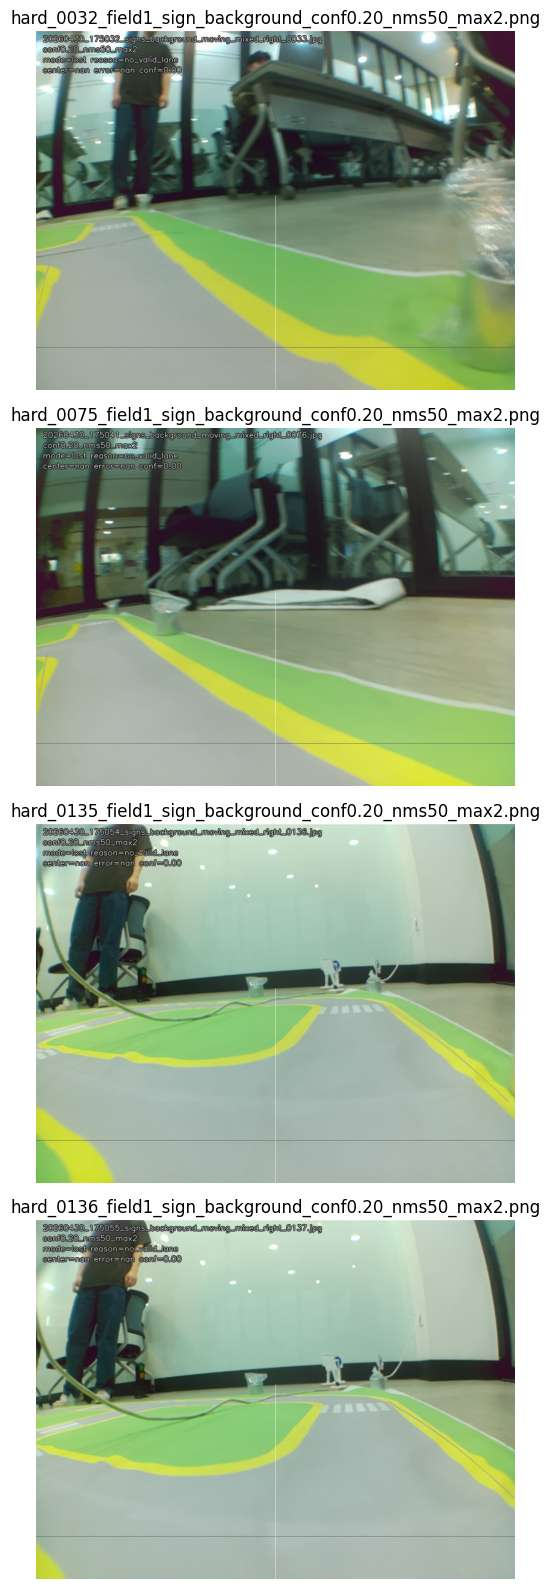

In [11]:
hard = primary_df.copy()
hard['rank_score'] = hard['abs_center_error_px'].fillna(9999)
hard = hard.sort_values(['rank_score', 'pred_confidence'], ascending=[False, True]).head(16).reset_index(drop=True)
display(hard[['sample_index', 'scene', 'file', 'gt_mode', 'pred_mode', 'abs_center_error_px', 'pred_confidence', 'pred_reason']])

hard_saved = []
for _, row in hard.iterrows():
    sample = samples[int(row['sample_index'])]
    out_path = OVERLAY_DIR / f'hard_{int(row["sample_index"]):04d}_{sample["scene"]}_{PRIMARY_SETTING.name}.png'
    vis, result = draw_drive_overlay(sample, PRIMARY_SETTING, out_path)
    hard_saved.append(str(out_path))

print('saved hard overlays:', len(hard_saved))
for p in hard_saved[:8]:
    print(p)

show_n = min(4, len(hard_saved))
fig, axes = plt.subplots(show_n, 1, figsize=(12, 4 * show_n))
if show_n == 1:
    axes = [axes]
for ax, path in zip(axes, hard_saved[:show_n]):
    img = cv2.cvtColor(cv2_imread_color(path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(Path(path).name)
plt.tight_layout()
plt.show()

## 11. 시계열 smoothing

single-frame 결과는 프레임마다 흔들릴 수 있음.

예:

```text
frame 1: both, center=640
frame 2: right_only, center=700
frame 3: lost
frame 4: both, center=625
```

이 값을 그대로 모터에 넣으면 차가 갑자기 좌우로 흔들림.  
따라서 짧은 시계열 상태를 유지함.

여기서는 가장 단순한 규칙부터 봄.

```text
if center detected:
    smoothed = alpha * current + (1-alpha) * previous
else if lost_frames <= MAX_LOST_HOLD_FRAMES:
    previous center 유지, confidence 감소
else:
    lost
```

이건 시계열 딥러닝이 아니라, 주행 제어에서 흔히 쓰는 상태 기반 smoothing임.

In [12]:
def temporal_smooth_sequence(df, alpha=CENTER_SMOOTH_ALPHA, max_lost_hold=MAX_LOST_HOLD_FRAMES):
    rows = []
    last_center = np.nan
    lost_count = 0
    for _, row in df.iterrows():
        current_center = row['pred_center_x']
        detected = np.isfinite(current_center)
        out = row.to_dict()

        if detected:
            if np.isfinite(last_center):
                smooth_center = alpha * current_center + (1 - alpha) * last_center
            else:
                smooth_center = current_center
            last_center = smooth_center
            lost_count = 0
            temporal_mode = row['pred_mode']
            temporal_confidence = row['pred_confidence']
            temporal_reason = 'detected_smoothed'
        else:
            lost_count += 1
            if np.isfinite(last_center) and lost_count <= max_lost_hold:
                smooth_center = last_center
                temporal_mode = 'hold_lost'
                temporal_confidence = max(0.0, 0.35 * (1 - lost_count / (max_lost_hold + 1)))
                temporal_reason = f'hold_previous_center_{lost_count}'
            else:
                smooth_center = np.nan
                temporal_mode = 'lost'
                temporal_confidence = 0.0
                temporal_reason = 'lost_too_long'

        out['temporal_center_x'] = smooth_center
        out['temporal_error_px'] = smooth_center - IMAGE_CENTER_X if np.isfinite(smooth_center) else np.nan
        out['temporal_error_norm'] = out['temporal_error_px'] / (RAW_W / 2) if np.isfinite(out['temporal_error_px']) else np.nan
        out['temporal_mode'] = temporal_mode
        out['temporal_confidence'] = temporal_confidence
        out['temporal_reason'] = temporal_reason
        out['lost_count'] = lost_count
        rows.append(out)
    return pd.DataFrame(rows)


# 실제 연속 주행에 가까운 background scene별로 smoothing을 따로 적용함.
temporal_parts = []
for scene, group in primary_df.sort_values(['scene', 'file']).groupby('scene'):
    temporal_parts.append(temporal_smooth_sequence(group.reset_index(drop=True)))
temporal_df = pd.concat(temporal_parts, ignore_index=True)

valid = temporal_df[np.isfinite(temporal_df['abs_center_error_px']) & np.isfinite(temporal_df['temporal_center_x'])].copy()
valid['temporal_abs_center_error_px'] = (valid['temporal_center_x'] - valid['gt_center_x']).abs()

print('single-frame median abs center error:', primary_df['abs_center_error_px'].median())
print('temporal median abs center error:', valid['temporal_abs_center_error_px'].median())
print('temporal mode distribution:')
display(temporal_df['temporal_mode'].value_counts())

temporal_df.to_csv(win_long_path(CSV_DIR / 'driving_temporal_results.csv'), index=False, encoding='utf-8-sig')

single-frame median abs center error: 18.110027793248463
temporal median abs center error: 41.154749513030936
temporal mode distribution:


temporal_mode
left_only     327
right_only    279
both           80
hold_lost      30
lost            6
Name: count, dtype: int64

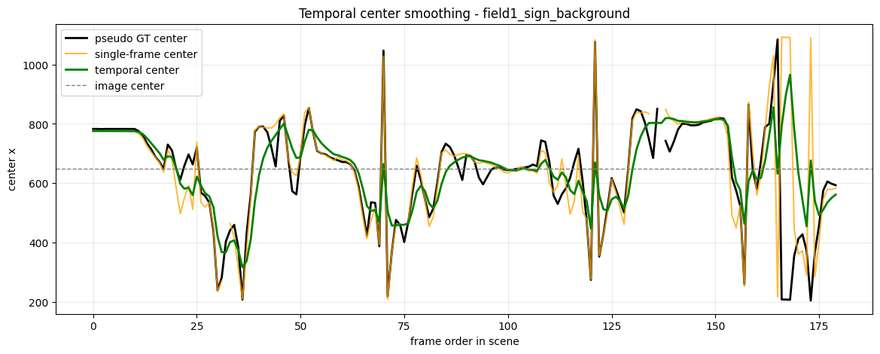

temporal_mode
left_only     84
right_only    78
both          13
hold_lost      5
Name: count, dtype: int64


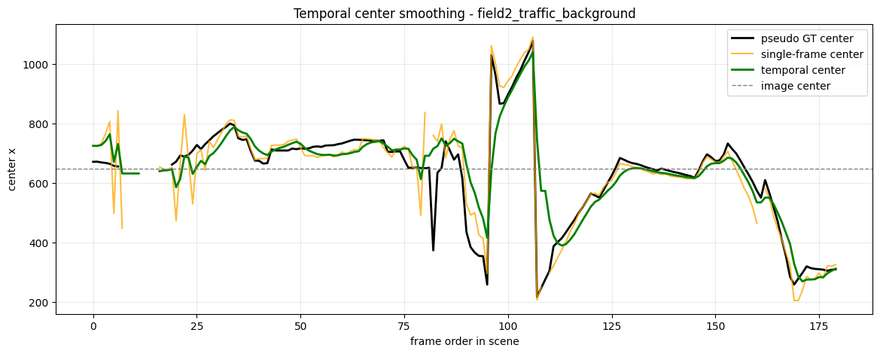

temporal_mode
right_only    73
left_only     73
both          23
hold_lost      7
lost           4
Name: count, dtype: int64


In [13]:
def plot_temporal_scene(scene_name, max_frames=180):
    seq = temporal_df[temporal_df['scene'] == scene_name].copy().reset_index(drop=True)
    if len(seq) == 0:
        print('no scene:', scene_name)
        return
    seq = seq.head(max_frames).copy()

    plt.figure(figsize=(14, 5))
    plt.plot(seq.index, seq['gt_center_x'], label='pseudo GT center', color='black', linewidth=2)
    plt.plot(seq.index, seq['pred_center_x'], label='single-frame center', color='orange', alpha=0.75)
    plt.plot(seq.index, seq['temporal_center_x'], label='temporal center', color='green', linewidth=2)
    plt.axhline(IMAGE_CENTER_X, color='gray', linestyle='--', linewidth=1, label='image center')
    plt.title(f'Temporal center smoothing - {scene_name}')
    plt.xlabel('frame order in scene')
    plt.ylabel('center x')
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

    mode_counts = seq['temporal_mode'].value_counts()
    print(mode_counts)


for scene in temporal_df['scene'].unique():
    plot_temporal_scene(scene, max_frames=180)

## 12. 제어 입력 형태로 변환

실제 Pi 주행 스크립트에서는 `center_x` 자체보다 아래 값이 더 바로 쓰임.

```text
error_norm = (center_x - image_center_x) / (image_width / 2)
```

이 값을 모터 제어에 넣으면 대략:

```text
turn = clamp(steer_gain * error_norm, -max_turn, +max_turn)
left_speed  = base_speed + turn
right_speed = base_speed - turn
```

다만 좌우 모터 방향은 실제 배선/모터 구현에 따라 부호가 바뀔 수 있음.  
이번 노트북은 아직 모터 명령을 확정하지 않고, `error_norm`, `confidence`, `mode`를 안정적으로 만드는 데 집중함.

In [14]:
def drive_command_from_error(error_norm, confidence, base_speed=0.28, steer_gain=0.75, max_turn=0.28, min_speed=0.12):
    if not np.isfinite(error_norm) or confidence <= 0:
        return {'left_speed': 0.0, 'right_speed': 0.0, 'turn': 0.0, 'speed_scale': 0.0, 'reason': 'no_valid_error'}

    # confidence가 낮으면 속도를 줄임.
    speed_scale = float(np.clip(0.45 + 0.55 * confidence, 0.25, 1.0))
    base = base_speed * speed_scale
    turn = float(np.clip(steer_gain * error_norm, -max_turn, max_turn))
    left = float(np.clip(base + turn, -1.0, 1.0))
    right = float(np.clip(base - turn, -1.0, 1.0))

    # 너무 작은 양수는 모터가 안 움직일 수 있으므로 최소 구동값을 적용.
    if left > 0:
        left = max(left, min_speed)
    if right > 0:
        right = max(right, min_speed)

    return {'left_speed': left, 'right_speed': right, 'turn': turn, 'speed_scale': speed_scale, 'reason': 'ok'}


cmd_rows = []
for _, row in temporal_df.iterrows():
    cmd = drive_command_from_error(row['temporal_error_norm'], row['temporal_confidence'])
    cmd_rows.append({
        'sample_index': row['sample_index'],
        'scene': row['scene'],
        'file': row['file'],
        'temporal_mode': row['temporal_mode'],
        'temporal_error_norm': row['temporal_error_norm'],
        'temporal_confidence': row['temporal_confidence'],
        **cmd,
    })
cmd_df = pd.DataFrame(cmd_rows)
cmd_df.to_csv(win_long_path(CSV_DIR / 'driving_command_preview.csv'), index=False, encoding='utf-8-sig')

display(cmd_df.head(20))
print('left/right speed summary:')
display(cmd_df[['left_speed', 'right_speed', 'turn', 'speed_scale']].describe())

,sample_index,scene,file,temporal_mode,temporal_error_norm,temporal_confidence,left_speed,right_speed,turn,speed_scale,reason
0,0,field1_sign_background,20260430_175024_signs_background_moving_mixed_...,left_only,0.197205,0.55,0.358604,0.120000,0.147904,0.7525,ok
1,1,field1_sign_background,20260430_175025_signs_background_moving_mixed_...,left_only,0.197300,0.55,0.358675,0.120000,0.147975,0.7525,ok
2,2,field1_sign_background,20260430_175025_signs_background_moving_mixed_...,left_only,0.197197,0.55,0.358598,0.120000,0.147898,0.7525,ok
3,3,field1_sign_background,20260430_175025_signs_background_moving_mixed_...,left_only,0.197185,0.55,0.358589,0.120000,0.147889,0.7525,ok
4,4,field1_sign_background,20260430_175025_signs_background_moving_mixed_...,left_only,0.197055,0.55,0.358491,0.120000,0.147791,0.7525,ok
5,5,field1_sign_background,20260430_175026_signs_background_moving_mixed_...,left_only,0.196954,0.55,0.358415,0.120000,0.147715,0.7525,ok
6,6,field1_sign_background,20260430_175026_signs_background_moving_mixed_...,left_only,0.197079,0.55,0.358509,0.120000,0.147809,0.7525,ok
7,7,field1_sign_background,20260430_175026_signs_background_moving_mixed_...,left_only,0.197139,0.55,0.358554,0.120000,0.147854,0.7525,ok
8,8,field1_sign_background,20260430_175026_signs_background_moving_mixed_...,left_only,0.197141,0.55,0.358556,0.120000,0.147856,0.7525,ok
9,9,field1_sign_background,20260430_175026_signs_background_moving_mixed_...,left_only,0.196837,0.55,0.358328,0.120000,0.147628,0.7525,ok


left/right speed summary:


,left_speed,right_speed,turn,speed_scale
count,722.000000,722.000000,722.000000,722.000000
mean,0.241143,0.205016,0.021137,0.765916
std,0.142414,0.139131,0.144999,0.112919
min,-0.110880,-0.084700,-0.280000,0.000000
25%,0.137952,0.120000,-0.070465,0.752500
50%,0.255298,0.183422,0.034288,0.752500
75%,0.343510,0.292018,0.120479,0.752500
max,0.560000,0.552731,0.280000,1.000000


## 13. 이번 노트북에서 결정해야 하는 것

실행 후 아래를 보고 판단함.

1. `EXPECTED_LANE_WIDTH_PX`가 pseudo GT 기준으로 합리적인가?
2. primary detector `conf=0.20, nms=50, max_lanes=2`가 driving center 계산에도 유지 가능한가?
3. `both`, `left_only`, `right_only`, `lost` 분포가 납득 가능한가?
4. hard overlay에서 초록 center가 주행 가능한 위치에 있는가?
5. temporal smoothing이 흔들림을 줄이되, 곡선 반응을 너무 늦게 만들지는 않는가?

아직 확정하지 않는 것:

- 실제 모터 속도
- `steer_gain`, `max_turn`
- 표지판/신호등 이벤트와의 통합

이 노트북이 끝나면 다음 단계는 두 갈래임.

```text
1. postprocess 결과가 괜찮음
   -> Pi 주행 스크립트로 포팅

2. postprocess 결과가 불안정함
   -> detector 설정/one-lane fallback/lane width prior 재조정
```

In [15]:
# 실행 결과를 반영한 판정 메모.
driving_postprocess_verdict = {
    'single_frame_primary_from_03': {
        'detector_setting': 'conf0.20_nms50_max2',
        'valid_center_frames': 676,
        'lost_frames': 36,
        'median_abs_center_error_px': 18.11,
        'p90_abs_center_error_px': 91.42,
    },
    'single_frame_better_for_driving_center': {
        'detector_setting': 'conf0.20_nms50_max4',
        'valid_center_frames': 687,
        'lost_frames': 24,
        'median_abs_center_error_px': 9.29,
        'p90_abs_center_error_px': 70.77,
    },
    'selected_next_detector_setting': 'conf0.20_nms50_max4',
    'lookahead_y': LOOKAHEAD_Y,
    'expected_lane_width_px': EXPECTED_LANE_WIDTH_PX,
    'temporal_result': {
        'current_temporal_base': 'conf0.20_nms50_max2',
        'single_frame_median_abs_center_error_px': 18.11,
        'temporal_median_abs_center_error_px': 41.15,
        'judgement': 'current smoothing worsened center error; do not port this temporal policy directly',
    },
    'next_action': (
        'revise driving postprocess around max_lanes=4, add duplicate/ghost suppression, '
        'then retest temporal smoothing with lower lag before Pi porting'
    ),
}
driving_postprocess_verdict


{'selected_detector_setting': 'conf0.20_nms50_max2',
 'lookahead_y': 856.06,
 'expected_lane_width_px': 889.7010498046875,
 'center_smooth_alpha': 0.35,
 'max_lost_hold_frames': 4,
 'next_action': 'run notebook, inspect overlays, then decide whether to port to Pi drive script'}

## 14. 실행 결과 메모

04 노트북은 에러 없이 실행되었고, 결과 CSV와 overlay가 정상 생성되었음.

이번 노트북에서 가장 중요한 발견은 **03의 detector 기준 최적값과 04의 driving center 기준 최적값이 다르다**는 점임.

03에서는 lane 후보 매칭 기준으로 `conf=0.20, nms=50, max_lanes=2`가 가장 균형이 좋아 보였음. 하지만 04에서 실제 주행에 필요한 `center_x`를 계산해 보니 `max_lanes=4`가 더 좋았음.

```text
conf0.20_nms50_max2
valid_center_frames        = 676 / 722
lost_frames                = 36
median_abs_center_error_px = 18.11
p90_abs_center_error_px    = 91.42
mean_confidence            = 0.572

conf0.20_nms50_max4
valid_center_frames        = 687 / 722
lost_frames                = 24
median_abs_center_error_px = 9.29
p90_abs_center_error_px    = 70.77
mean_confidence            = 0.726
```

즉 후보를 2개만 남기면 detector 평가에서는 깔끔하지만, 실제 centerline 계산에서는 필요한 좌우 후보가 누락되는 경우가 많았음. 반대로 `max_lanes=4`는 ghost 후보가 늘어날 수 있지만, 현재 lane pair 선택 로직이 좌우 후보를 고를 수 있어서 center 계산은 더 안정적이었음.

장면별로도 같은 경향이 나왔음.

```text
field1_sign_background
max2: median 17.9 px, p90 92.4 px
max4: median  8.7 px, p90 83.5 px

field2_traffic_background
max2: median 18.9 px, p90 91.3 px
max4: median 10.2 px, p90 58.4 px
```

따라서 다음 driving postprocess 후보는 아래로 바꾸는 것이 맞음.

```text
detector_setting_for_driving = {
    conf_threshold: 0.20,
    nms_thres: 50,
    max_lanes: 4
}
```

다만 `max_lanes=4`를 그대로 Pi 주행에 넣는다는 뜻은 아님. 후보를 더 많이 살리는 대신, 다음 단계에서 duplicate/ghost lane 제거와 lane pair 선택 정책을 더 정교하게 해야 함.

`EXPECTED_LANE_WIDTH_PX`는 pseudo GT 기준 약 `889.7 px`로 추정되었음. 이 값은 한쪽 lane만 보일 때 center를 추정하는 데 쓰였고, 대표 overlay에서는 대체로 말이 되는 위치를 만들었음. 다만 one-lane fallback은 실제 주행에서 위험할 수 있으므로, confidence를 낮게 두고 감속 조건과 함께 써야 함.

현재 temporal smoothing은 그대로 쓰면 안 됨.

```text
single-frame median abs center error = 18.11 px
temporal median abs center error     = 41.15 px
```

즉 지금의 smoothing은 흔들림을 줄이기보다 곡선/전환 구간에서 반응을 늦춰 error를 키웠음. 또한 현재 temporal 실험은 `max_lanes=2` 결과를 기준으로만 수행되었으므로, 다음에는 `max_lanes=4` 기반으로 다시 실험해야 함.

정리하면, 이번 노트북의 결론은 다음과 같음.

1. lane detector 출력 좌표를 driving center로 바꾸는 기본 구조는 동작함.
2. detector 기준 최적값인 `max_lanes=2`보다, driving center 기준으로는 `max_lanes=4`가 더 좋음.
3. one-lane fallback은 필요하지만 confidence/감속과 묶어야 함.
4. 현재 temporal smoothing은 실패에 가까우므로 바로 Pi로 포팅하면 안 됨.
5. 다음 작업은 `max_lanes=4` 기준으로 lane pair 선택, ghost 제거, smoothing 정책을 다시 정리하는 것임.
